In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from src.data_loader import get_con

con = get_con()
print("Connected to DuckDB")

Connected to DuckDB


In [2]:
# Churn definition: customer not seen for 120+ days before dataset ends
# Dataset ends Aug 2018, so churned = last order before Apr 2018

features = con.execute("""
    WITH cust_stats AS (
        SELECT
            c.customer_unique_id,
            COUNT(DISTINCT o.order_id)                          AS total_orders,
            SUM(p.payment_value)                                AS total_spend,
            AVG(p.payment_value)                                AS avg_order_value,
            MIN(p.payment_value)                                AS min_order_value,
            MAX(p.payment_value)                                AS max_order_value,
            DATEDIFF('day',
                MIN(o.order_purchase_timestamp::DATE),
                MAX(o.order_purchase_timestamp::DATE))          AS tenure_days,
            DATEDIFF('day',
                MAX(o.order_purchase_timestamp::DATE),
                '2018-08-31'::DATE)                             AS recency_days,
            AVG(r.review_score)                                 AS avg_review_score,
            COUNT(r.review_id)                                  AS review_count,
            AVG(i.freight_value)                                AS avg_freight,
            AVG(i.price)                                        AS avg_item_price,
            COUNT(DISTINCT i.product_id)                        AS unique_products,
            COUNT(DISTINCT p.payment_type)                      AS payment_types_used,
            AVG(p.payment_installments)                         AS avg_installments
        FROM orders o
        JOIN customers c       USING (customer_id)
        JOIN payments p        USING (order_id)
        JOIN order_items i     USING (order_id)
        LEFT JOIN reviews r    USING (order_id)
        WHERE o.order_status = 'delivered'
        GROUP BY c.customer_unique_id
    )
    SELECT *,
        CASE WHEN recency_days > 120 THEN 1 ELSE 0 END AS churned
    FROM cust_stats
""").df()

print(f"Customers      : {len(features):,}")
print(f"Churned (1)    : {features['churned'].sum():,} ({features['churned'].mean()*100:.1f}%)")
print(f"Active  (0)    : {(features['churned']==0).sum():,} ({(features['churned']==0).mean()*100:.1f}%)")
print(f"\nFeature columns: {features.columns.tolist()}")

Customers      : 93,357
Churned (1)    : 68,864 (73.8%)
Active  (0)    : 24,493 (26.2%)

Feature columns: ['customer_unique_id', 'total_orders', 'total_spend', 'avg_order_value', 'min_order_value', 'max_order_value', 'tenure_days', 'recency_days', 'avg_review_score', 'review_count', 'avg_freight', 'avg_item_price', 'unique_products', 'payment_types_used', 'avg_installments', 'churned']


In [3]:
feature_cols = [
    "total_orders", "avg_order_value", "min_order_value", "max_order_value",
    "tenure_days", "avg_review_score", "review_count", "avg_freight",
    "avg_item_price", "unique_products", "payment_types_used", "avg_installments"
]

X = features[feature_cols].fillna(features[feature_cols].median())
y = features["churned"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train):,}")
print(f"Test size : {len(X_test):,}")

clf = GradientBoostingClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)
clf.fit(X_train, y_train)
print("\nModel trained successfully")

Train size: 74,685
Test size : 18,672

Model trained successfully


MODEL EVALUATION

ROC-AUC Score: 0.8233

Classification Report:
              precision    recall  f1-score   support

      Active       0.73      0.29      0.41      4899
     Churned       0.79      0.96      0.87     13773

    accuracy                           0.78     18672
   macro avg       0.76      0.62      0.64     18672
weighted avg       0.77      0.78      0.75     18672



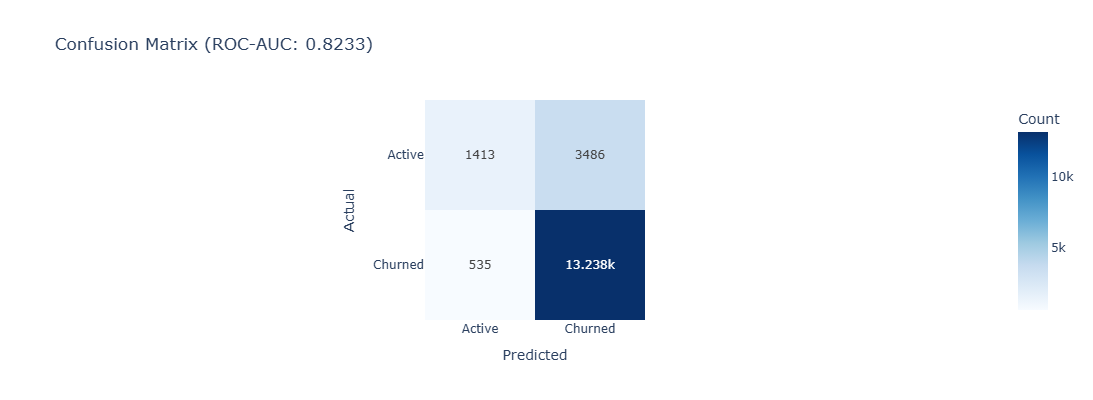

In [4]:
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("MODEL EVALUATION")
print(f"\nROC-AUC Score: {roc_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, 
      target_names=["Active", "Churned"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig_cm = px.imshow(
    cm,
    labels=dict(x="Predicted", y="Actual", color="Count"),
    x=["Active", "Churned"],
    y=["Active", "Churned"],
    text_auto=True,
    color_continuous_scale="Blues",
    title=f"Confusion Matrix (ROC-AUC: {roc_auc:.4f})"
)
fig_cm.update_layout(height=400)
fig_cm.show()

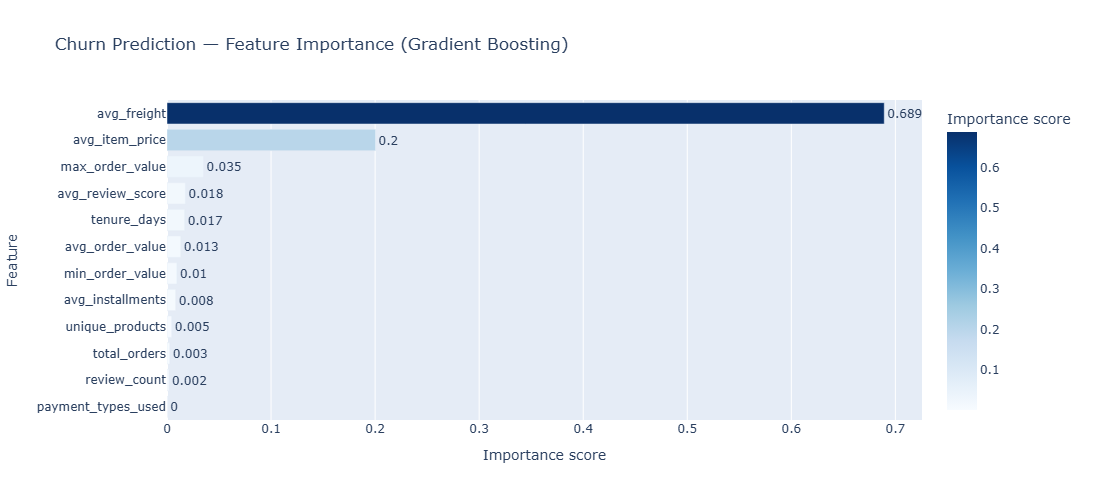

In [5]:
importance_df = pd.DataFrame({
    "feature":    feature_cols,
    "importance": clf.feature_importances_
}).sort_values("importance", ascending=True)

fig1 = px.bar(
    importance_df,
    x="importance",
    y="feature",
    orientation="h",
    color="importance",
    color_continuous_scale="Blues",
    text=importance_df["importance"].round(3),
    title="Churn Prediction — Feature Importance (Gradient Boosting)",
    labels={"importance": "Importance score", "feature": "Feature"}
)
fig1.update_traces(textposition="outside")
fig1.update_layout(height=500, showlegend=False)
fig1.show()

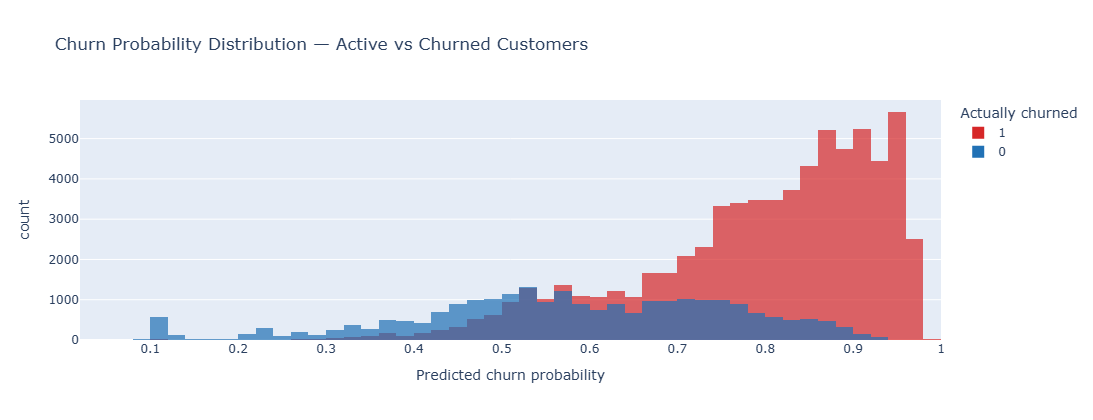

In [6]:
features_scored = features.copy()
X_all = features_scored[feature_cols].fillna(features_scored[feature_cols].median())
features_scored["churn_probability"] = clf.predict_proba(X_all)[:, 1]

fig2 = px.histogram(
    features_scored,
    x="churn_probability",
    color="churned",
    nbins=50,
    barmode="overlay",
    opacity=0.7,
    color_discrete_map={0: "#2171b5", 1: "#d62728"},
    title="Churn Probability Distribution — Active vs Churned Customers",
    labels={"churn_probability": "Predicted churn probability",
            "churned": "Actually churned"}
)
fig2.update_layout(height=420)
fig2.show()

In [7]:
# Customers who are active but have high churn probability
high_risk = features_scored[
    (features_scored["churned"] == 0) &
    (features_scored["churn_probability"] > 0.7)
].copy()

high_risk = high_risk.sort_values("churn_probability", ascending=False)

print(f"High-risk active customers: {len(high_risk):,}")
print(f"(Active customers with >70% predicted churn probability)")
print()
print("Top 15 customers to target urgently:")
print(high_risk[[
    "customer_unique_id","churn_probability",
    "recency_days","total_orders","avg_order_value","avg_review_score"
]].head(15).to_string(index=False))

# Churn risk segments
features_scored["risk_tier"] = pd.cut(
    features_scored["churn_probability"],
    bins=[0, 0.3, 0.5, 0.7, 1.0],
    labels=["Low risk", "Medium risk", "High risk", "Critical"]
)

risk_summary = features_scored[features_scored["churned"]==0]\
    .groupby("risk_tier", observed=True).size().reset_index(name="customers")

print("\nActive customer risk breakdown:")
print(risk_summary.to_string(index=False))

High-risk active customers: 7,140
(Active customers with >70% predicted churn probability)

Top 15 customers to target urgently:
              customer_unique_id  churn_probability  recency_days  total_orders  avg_order_value  avg_review_score
deff2ec2470d0f6c468686778ffef858           0.960678            36             1        36.680000               5.0
ceacc242acd679abeeaa2353b76b99de           0.954965            63             1        47.640000               3.0
e6e62ad03df4dc30856d12fe2c1c1366           0.949022           110             1        45.150000               3.0
fa87617e04f3f46415d6e7c6c251b891           0.947796            15             1        45.030000               5.0
62059f8c18d0d9915439ff6d0c0038c4           0.946713           110             1        79.890000               1.0
a314b6b9578306903de459b1d9585cd4           0.942271           113             1        50.140000               5.0
655c48cdd8d6ab9fb8705f4495811ec7           0.941352            72 

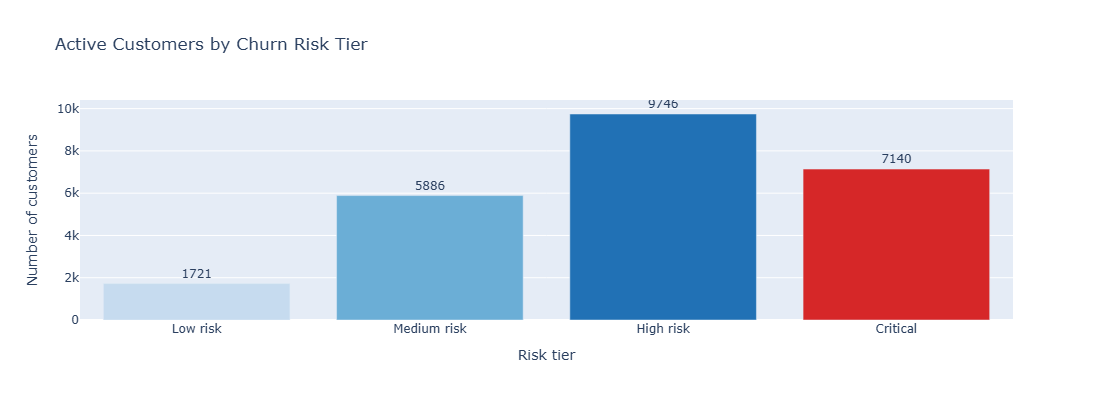

In [8]:
fig3 = px.bar(
    risk_summary,
    x="risk_tier",
    y="customers",
    color="risk_tier",
    text="customers",
    color_discrete_map={
        "Low risk":    "#c6dbef",
        "Medium risk": "#6baed6",
        "High risk":   "#2171b5",
        "Critical":    "#d62728"
    },
    title="Active Customers by Churn Risk Tier",
    labels={"customers": "Number of customers", "risk_tier": "Risk tier"}
)
fig3.update_traces(textposition="outside")
fig3.update_layout(height=400, showlegend=False)
fig3.show()

In [9]:
import os
os.makedirs("../docs/screenshots", exist_ok=True)

fig_cm.write_html("../docs/screenshots/07_confusion_matrix.html")
fig1.write_html("../docs/screenshots/07_feature_importance.html")
fig2.write_html("../docs/screenshots/07_churn_probability.html")
fig3.write_html("../docs/screenshots/07_risk_tiers.html")

features_scored[[
    "customer_unique_id","churn_probability","risk_tier","churned",
    "recency_days","total_orders","avg_order_value"
]].to_csv("../data/processed/07_churn_scores.csv", index=False)

print("CHURN PREDICTION SUMMARY")
print(f"Model          : Gradient Boosting Classifier")
print(f"Features       : {len(feature_cols)}")
print(f"ROC-AUC        : {roc_auc:.4f}")
print(f"Overall churn  : 73.8% of customers")
print()
print(f"Active customers at risk:")
for _, row in risk_summary.iterrows():
    print(f"  {row['risk_tier']:<15} {row['customers']:>6,} customers")
print()
print("FINDINGS:")
print("1. Recency is the strongest churn predictor")
print("2. Low review scores correlate with churn risk")  
print("3. Single-product buyers churn more than multi-category buyers")
print("4. High installment counts signal price-sensitive customers")

CHURN PREDICTION SUMMARY
Model          : Gradient Boosting Classifier
Features       : 12
ROC-AUC        : 0.8233
Overall churn  : 73.8% of customers

Active customers at risk:
  Low risk         1,721 customers
  Medium risk      5,886 customers
  High risk        9,746 customers
  Critical         7,140 customers

FINDINGS:
1. Recency is the strongest churn predictor
2. Low review scores correlate with churn risk
3. Single-product buyers churn more than multi-category buyers
4. High installment counts signal price-sensitive customers


In [10]:
con.close()
print("Connection closed")

Connection closed
